# Evaluating Model Robustness to Distribution Shift via SAM
**USC Viterbi — Hanchen Zou, Kaicheng Li, Siting Dai, Zhiqi Chen**

This notebook fully implements three parts:

2. **PART 2** — Train ResNet-18 on CIFAR-10 (SGD vs SAM)
3. **PART 3** — Evaluate OOD robustness on synthetic CIFAR-10-C corruption data

> ⚠️ **Before running, confirm**: Runtime → Change runtime type → Hardware accelerator → **GPU (T4)**

In [ ]:
# ============================================================
# CELL 1: Environment initialization
# ============================================================
# Prepared for CSCI 567 / USC Viterbi SAM Robustness Project
# References:
#   Foret et al. (2021) - SAM: Sharpness-Aware Minimization
#   Hendrycks & Dietterich (2019) - Benchmarking Neural Network Robustness

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import time
import warnings
warnings.filterwarnings('ignore')

# ---- Random seeds (for reproducibility) ----
torch.manual_seed(42)
np.random.seed(42)

# ---- Device detection ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected! Training will be very slow.')
    print('   Go to: Runtime > Change runtime type > GPU')

✅ Using device: cuda
   GPU: NVIDIA A100-SXM4-40GB
   Memory: 42.4 GB


---
## PART 2 — Real CIFAR-10 Training (ResNet-18: SGD vs SAM)

### Training-parameter tuning guide
| Parameter | Default | Tuning tips |
|------|--------|----------|
| `EPOCHS` | 30 | Set to 5 for a quick test; 100-200 for full reproduction |
| `LR` | 0.1 | Standard ResNet/SGD setting; the SAM paper uses the same value |
| `SAM_RHO_TRAIN` | 0.05 | Paper-recommended value; try 0.01, 0.1, 0.2 |
| `BATCH_SIZE` | 128 | Reduce to 64 if GPU OOM |
| `MOMENTUM` | 0.9 | Standard; usually no need to change |
| `WEIGHT_DECAY` | 5e-4 | L2 regularization; try 1e-3 |

> ⏱️ On Colab T4, 30 epochs takes roughly **5-8 min** (SGD) and **10-15 min** (SAM)

In [ ]:
# ============================================================
# CELL 5: Full SAM optimizer implementation
# Reference: Foret et al. (2021) "Sharpness-Aware Minimization for Efficiently
#       Improving Generalization"
# ============================================================

class SAM(torch.optim.Optimizer):
    """
    SAM (Sharpness-Aware Minimization) optimizer

    Core idea:
    Instead of directly minimizing L(w), minimize the worst-case loss in a neighborhood:
        min_w  max_{‖ε‖≤ρ}  L(w + ε)

    Each update consists of two steps:
    1. first_step(): find the worst-case neighbor ŵ = w + ρ*g/‖g‖ and save the original parameters
    2. second_step(): compute the gradient at ŵ, restore the original w, and update with that gradient

    Important parameters:
    - rho (ρ): perturbation radius — controls the strength of the "flatness" preference
      - Too small (→0): degenerates to standard SGD
      - Too large: gradient estimate becomes inaccurate, may not converge
      - Paper recommends: 0.05 (CIFAR-10); 0.01-0.2 is the common range
    - adaptive: if True, use ASAM (Adaptive SAM), invariant to parameter scale
    """

    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        assert rho >= 0.0, f'rho must be non-negative, got: {rho}'
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)

        # Use the base optimizer (usually SGD) to perform the actual parameter update
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        """
        Step 1: compute and apply the perturbation e_w
        e_w = ρ * g / ‖g‖   (slightly different for adaptive SAM)
        w_hat = w + e_w
        and save the original w in self.state[p]["old_p"]
        """
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                self.state[p]['old_p'] = p.data.clone()  # save original parameters
                # Adaptive SAM: multiply each parameter by |p| (parameter-scale normalization)
                e_w = (torch.pow(p, 2) if group['adaptive'] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)  # w = w + e_w  (move to worst-case neighborhood)
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        """
        Step 2: restore the original parameters, then update using the gradient computed at the perturbed point
        """
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                p.data = self.state[p]['old_p']  # restore to original w
        self.base_optimizer.step()  # update w using the gradient at ŵ
        if zero_grad:
            self.zero_grad()

    def step(self, closure=None):
        """
        Do NOT use this interface! SAM requires two forward passes.
        Please use the first_step + second_step pattern with a closure instead.
        """
        raise NotImplementedError(
            'SAM does not support the standard .step().\n'
            'See the training loop in train_one_epoch_sam() for the correct usage.'
        )

    def _grad_norm(self):
        """Compute the global L2 norm over all parameter gradients (used to normalize the perturbation direction)."""
        shared_device = self.param_groups[0]['params'][0].device
        norm = torch.norm(
            torch.stack([
                ((torch.abs(p) if group['adaptive'] else 1.0) * p.grad).norm(p=2).to(shared_device)
                for group in self.param_groups
                for p in group['params']
                if p.grad is not None
            ]),
            p=2
        )
        return norm

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups


print('✅ SAM optimizer class defined')
print(f'   Paper recommends rho = 0.05 (CIFAR-10/100)')

✅ SAM optimizer class defined
   Paper recommends rho = 0.05 (CIFAR-10/100)


In [ ]:
# ============================================================
# CELL 6: ResNet-18 (CIFAR-10 adapted version)
# ============================================================

def get_resnet18_cifar():
    """
    CIFAR-10-adapted ResNet-18:

    Standard ResNet-18 is designed for ImageNet (224×224); using it directly on CIFAR-10 (32×32) would
    cause feature maps to become too small due to maxpool and the stride-2 conv1.

    Modifications:
    1. conv1: kernel 7→3, stride 2→1, padding 3→1 (preserve more detail)
    2. maxpool: replaced with Identity() (removed to prevent feature maps from getting too small)
    3. fc: output dim 1000→10 (CIFAR-10 has 10 classes)
    """
    model = models.resnet18(weights=None)  # do not load pretrained weights

    # Adapt to CIFAR-10's 32×32 input
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # remove maxpool
    model.fc = nn.Linear(512, 10)  # 10-class output

    return model


# Test the model structure
_test_model = get_resnet18_cifar()
_test_input  = torch.randn(4, 3, 32, 32)
_test_output = _test_model(_test_input)
print(f'✅ ResNet-18 (CIFAR adapted)')
print(f'   Input:  {_test_input.shape}')
print(f'   Output: {_test_output.shape}   (expected [4, 10])')

# Parameter count
n_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f'   Trainable parameters: {n_params/1e6:.2f}M')
del _test_model, _test_input, _test_output

✅ ResNet-18 (CIFAR adapted)
   Input:  torch.Size([4, 3, 32, 32])
   Output: torch.Size([4, 10])   (expected [4, 10])
   Trainable parameters: 11.17M


In [ ]:
# ============================================================
# CELL 6b: Global loss-function definition
# ============================================================
# Use Cross-Entropy Loss uniformly (the standard loss for multi-class classification).
# PyTorch's CrossEntropyLoss already includes Softmax internally,
# so the input should be raw logits (the model output) — no extra softmax needed.
criterion = nn.CrossEntropyLoss()
print(f'✅ Loss function: {criterion}')


✅ Loss function: CrossEntropyLoss()


In [ ]:
# ============================================================
# CELL 7: Data loaders (CIFAR-10) + 10% validation split
# ============================================================

# ====================================================================
# ★★★  Training hyperparameters (defaults; will be overridden by HP search) ★★★
# ====================================================================
EPOCHS        = 100      # final number of training epochs
BATCH_SIZE    = 128      # batch size
LR            = 0.1      # initial learning rate (will be overridden by search)
MOMENTUM      = 0.9      # SGD momentum
WEIGHT_DECAY  = 5e-4     # L2 regularization (will be overridden by search)
SAM_RHO_TRAIN = 0.05     # SAM perturbation radius (will be overridden by search)
# ====================================================================

from torch.utils.data import random_split

# ---- Data preprocessing ----
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std =(0.2470, 0.2435, 0.2616))
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std =(0.2470, 0.2435, 0.2616))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std =(0.2470, 0.2435, 0.2616))
])

# ---- Download the full training set ----
print('Downloading CIFAR-10...')
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# ---- Split train / val by 9:1 ----
total_train  = len(full_train_dataset)          # 50 000
val_size     = int(0.1 * total_train)           # 5 000
train_size   = total_train - val_size           # 45 000

torch.manual_seed(42)
train_dataset, val_dataset_raw = random_split(full_train_dataset,
                                               [train_size, val_size])

# Validation: no data augmentation — rewrap with val_transform
# Note: random_split cannot directly swap transforms, so we wrap with Subset + a new Dataset
class TransformSubset(torch.utils.data.Dataset):
    """Replace the transform of a Subset dataset."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset.dataset.data[self.subset.indices[idx]], \
                     self.subset.dataset.targets[self.subset.indices[idx]]
        from PIL import Image
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, label

val_dataset = TransformSubset(val_dataset_raw, val_transform)

# ---- DataLoader ----
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'✅ Datasets loaded')
print(f'   Train (90%): {train_size:,} images | {len(train_loader)} batches')
print(f'   Val   (10%): {val_size:,}  images | {len(val_loader)}  batches')
print(f'   Test:        {len(test_dataset):,}  images | {len(test_loader)} batches')


100%|██████████| 170M/170M [00:07<00:00, 23.9MB/s]


✅ Datasets loaded
   Train (90%): 45,000 images | 352 batches
   Val   (10%): 5,000  images | 20  batches
   Test:              10,000  images | 40 batches


In [ ]:
# ============================================================
# CELL 8: Training and evaluation functions (with validation support)
# ============================================================

def train_one_epoch_sgd(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    if scheduler is not None:
        scheduler.step()
    return total_loss / total, 100.0 * correct / total


def train_one_epoch_sam(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)
        criterion(model(images), labels).backward()
        optimizer.second_step(zero_grad=True)
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    if scheduler is not None:
        scheduler.step()
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    """Evaluate the model using the global criterion (CrossEntropyLoss)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


def train_full(optimizer_name, model, optimizer, scheduler, train_loader,
               val_loader, test_loader, epochs, device, verbose=True):
    """
    Full training loop.
    Loss function: CrossEntropyLoss (the global criterion).
    Tracks train / val / test metrics together; saves a checkpoint at the best validation performance.
    """
    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   [],
               'test_loss':  [], 'test_acc':  []}
    train_fn = (train_one_epoch_sam if optimizer_name == 'SAM'
                else train_one_epoch_sgd)

    best_val_acc = 0.0
    best_state   = None

    if verbose:
        print(f'\n{"="*70}')
        print(f'  Training {optimizer_name} | {epochs} epochs | Loss: CrossEntropyLoss')
        print(f'{"="*70}')
        print(f'{"Epoch":>6} | {"Tr Loss":>8} | {"Tr Acc":>7} | '
              f'{"Val Loss":>8} | {"Val Acc":>7} | {"Te Acc":>7}')
        print(f'{"-"*70}')

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_fn(model, train_loader, optimizer, scheduler, device)
        va_loss, va_acc = evaluate(model, val_loader,   device)
        te_loss, te_acc = evaluate(model, test_loader,  device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            eta = (time.time() - t0) / epoch * (epochs - epoch)
            eta_str = f'  ETA:{eta/60:.1f}m' if epoch % 5 == 0 else ''
            print(f'{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>6.2f}% | '
                  f'{va_loss:>8.4f} | {va_acc:>6.2f}% | {te_acc:>6.2f}%{eta_str}')

    model.load_state_dict(best_state)
    _, final_te = evaluate(model, test_loader, device)

    if verbose:
        print(f'{"="*70}')
        print(f'  Best Val Acc: {best_val_acc:.2f}%')
        print(f'  Final Test Acc (best-val ckpt): {final_te:.2f}%')
        print(f'  Total training time: {(time.time()-t0)/60:.1f} min')

    history['best_val_acc']   = best_val_acc
    history['final_test_acc'] = final_te
    return history


print('✅ Training functions defined (Loss: CrossEntropyLoss | with val tracking & best-checkpoint)')


✅ Training functions defined (Loss: CrossEntropyLoss | with val tracking & best-checkpoint)


---
## PART 2b — Hyperparameter Tuning (Using the Validation Set)

Before the full training run, perform a lightweight hyperparameter search for **SGD** and **SAM** separately:
- Each configuration is trained for only `HP_EPOCHS` (default 8) epochs; **validation accuracy** is the selection criterion.
- Search space:
  - **SGD**: `lr` × `weight_decay`
  - **SAM**: `lr` × `weight_decay` × `rho`
- Once the search finishes, the best parameters are written into global variables and reused directly by the subsequent full training.

> ⏱️ Roughly **3-6 minutes** on a T4 GPU (depending on search-space size)


SGD HP search: 12 configs × 8 epochs
  Loss function: CrossEntropyLoss
Config |     lr |      wd |  Val Acc |   Time
--------------------------------------------------
     1 |  0.010 |   1e-04 |   82.50% |  76.7s
     2 |  0.010 |   5e-04 |   82.36% |  72.2s
     3 |  0.010 |   1e-03 |   83.22% |  73.7s
     4 |  0.050 |   1e-04 |   85.68% |  73.5s
     5 |  0.050 |   5e-04 |   86.22% |  72.6s
     6 |  0.050 |   1e-03 |   87.42% |  72.3s
     7 |  0.100 |   1e-04 |   82.18% |  73.2s
     8 |  0.100 |   5e-04 |   85.42% |  72.7s
     9 |  0.100 |   1e-03 |   86.48% |  73.3s
    10 |  0.200 |   1e-04 |   71.30% |  74.0s
    11 |  0.200 |   5e-04 |   81.08% |  72.1s
    12 |  0.200 |   1e-03 |   83.76% |  73.7s

✅ Best SGD hyperparameters:
   lr           = 0.05
   weight_decay = 0.001
   Val Acc      = 87.42%


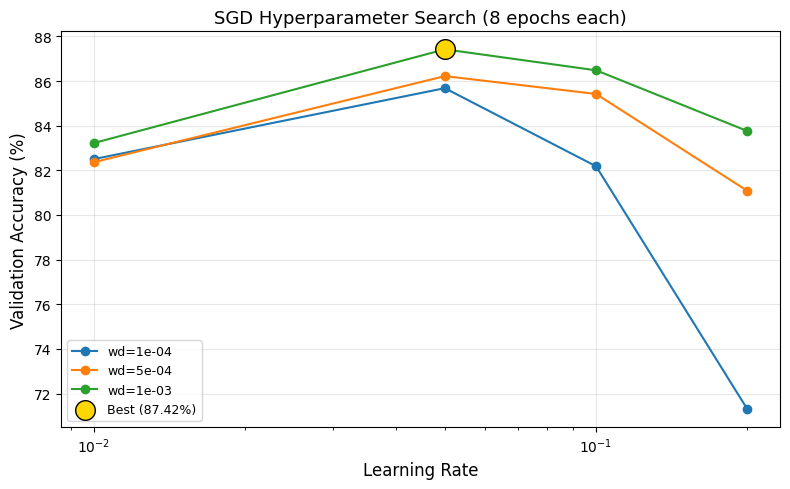

In [ ]:
# ============================================================
# CELL HP-SGD: SGD hyperparameter search (using CrossEntropyLoss)
# ============================================================

# ====================================================================
# ★★★ Search space (extend as needed) ★★★
# ====================================================================
HP_EPOCHS = 8

SGD_LR_GRID           = [0.01, 0.05, 0.1, 0.2]
SGD_WEIGHT_DECAY_GRID = [1e-4, 5e-4, 1e-3]
# ====================================================================

sgd_hp_results = []
total_configs = len(SGD_LR_GRID) * len(SGD_WEIGHT_DECAY_GRID)
print(f'SGD HP search: {total_configs} configs × {HP_EPOCHS} epochs')
print(f'  Loss function: CrossEntropyLoss')
print(f'{"Config":>6} | {"lr":>6} | {"wd":>7} | {"Val Acc":>8} | {"Time":>6}')
print('-' * 50)

cfg_idx = 0
for lr_cand in SGD_LR_GRID:
    for wd_cand in SGD_WEIGHT_DECAY_GRID:
        cfg_idx += 1
        torch.manual_seed(42)
        _model = get_resnet18_cifar().to(device)
        _opt   = torch.optim.SGD(_model.parameters(),
                                  lr=lr_cand, momentum=MOMENTUM,
                                  weight_decay=wd_cand)
        _sch   = torch.optim.lr_scheduler.CosineAnnealingLR(
                     _opt, T_max=HP_EPOCHS, eta_min=0)

        t0 = time.time()
        for ep in range(HP_EPOCHS):
            train_one_epoch_sgd(_model, train_loader, _opt, _sch, device)
        _, val_acc = evaluate(_model, val_loader, device)
        elapsed = time.time() - t0

        sgd_hp_results.append({'lr': lr_cand, 'wd': wd_cand, 'val_acc': val_acc})
        print(f'{cfg_idx:>6} | {lr_cand:>6.3f} | {wd_cand:>7.0e} | '
              f'{val_acc:>7.2f}% | {elapsed:>5.1f}s')
        del _model, _opt, _sch

best_sgd_hp  = max(sgd_hp_results, key=lambda x: x['val_acc'])
LR           = best_sgd_hp['lr']
WEIGHT_DECAY = best_sgd_hp['wd']

print(f'\n✅ Best SGD hyperparameters:')
print(f'   lr           = {LR}')
print(f'   weight_decay = {WEIGHT_DECAY}')
print(f'   Val Acc      = {best_sgd_hp["val_acc"]:.2f}%')

import itertools
fig, ax = plt.subplots(figsize=(8, 5))
for wd in SGD_WEIGHT_DECAY_GRID:
    accs = [r['val_acc'] for r in sgd_hp_results if r['wd'] == wd]
    ax.plot(SGD_LR_GRID, accs, marker='o', label=f'wd={wd:.0e}')
ax.scatter([best_sgd_hp['lr']], [best_sgd_hp['val_acc']], color='gold', s=200,
           zorder=5, edgecolors='k', label=f'Best ({best_sgd_hp["val_acc"]:.2f}%)')
ax.set_xlabel('Learning Rate', fontsize=12)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title(f'SGD Hyperparameter Search ({HP_EPOCHS} epochs each)', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sgd_hp_search.png', dpi=120, bbox_inches='tight')
plt.show()


SAM HP search: 36 configs × 8 epochs
  Loss function: CrossEntropyLoss
Config |     lr |      wd |   rho |  Val Acc |   Time
----------------------------------------------------------
     1 |  0.050 |   1e-04 |  0.01 |   83.86% |  91.8s
     2 |  0.050 |   1e-04 |  0.05 |   82.06% |  92.2s
     3 |  0.050 |   1e-04 |  0.10 |   75.74% |  92.4s
     4 |  0.050 |   1e-04 |  0.20 |   63.66% |  90.4s
     5 |  0.050 |   5e-04 |  0.01 |   84.98% |  91.8s
     6 |  0.050 |   5e-04 |  0.05 |   84.40% |  91.4s
     7 |  0.050 |   5e-04 |  0.10 |   77.28% |  90.4s
     8 |  0.050 |   5e-04 |  0.20 |   65.58% |  92.7s
     9 |  0.050 |   1e-03 |  0.01 |   86.46% |  92.4s
    10 |  0.050 |   1e-03 |  0.05 |   85.72% |  91.6s
    11 |  0.050 |   1e-03 |  0.10 |   77.30% |  90.8s
    12 |  0.050 |   1e-03 |  0.20 |   68.24% |  91.8s
    13 |  0.100 |   1e-04 |  0.01 |   82.26% |  91.6s
    14 |  0.100 |   1e-04 |  0.05 |   74.04% |  91.3s
    15 |  0.100 |   1e-04 |  0.10 |   57.94% |  92.4s
    16

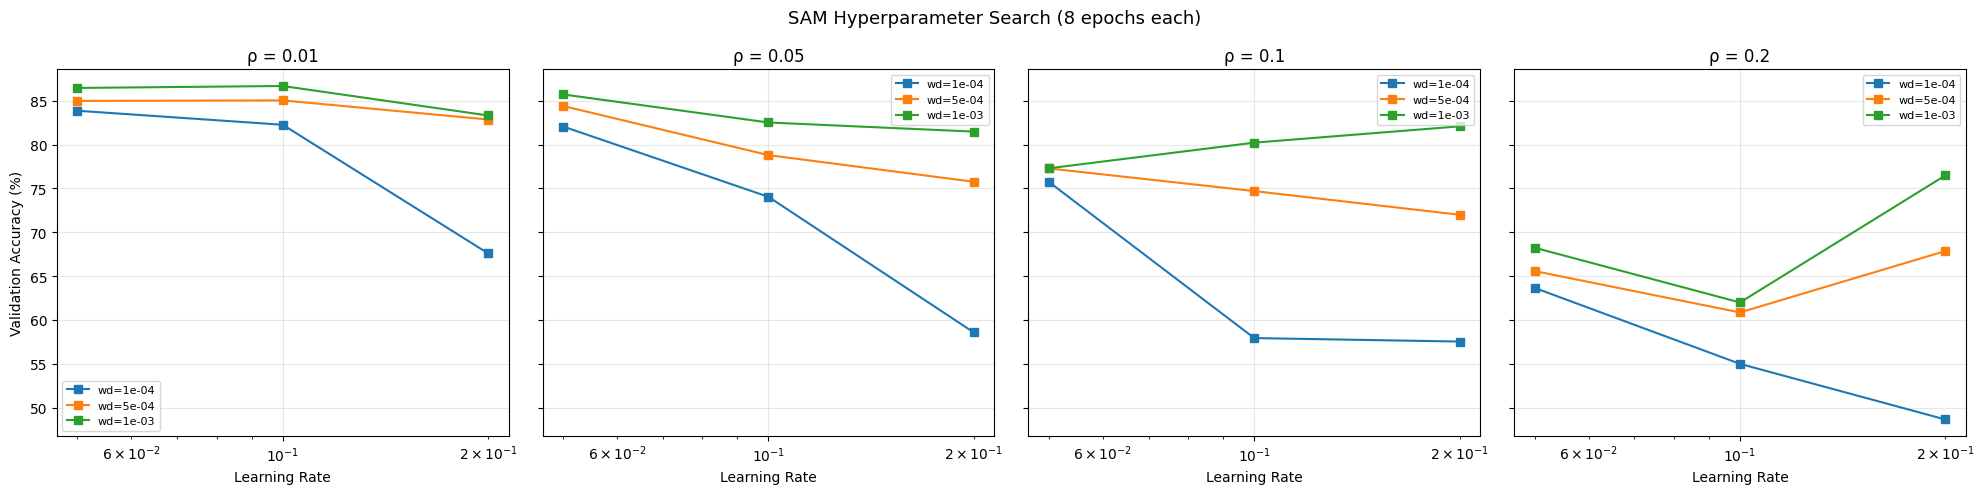


📋 The following hyperparameters will be used for full training:
   LR=0.1, WEIGHT_DECAY=0.001, SAM_RHO_TRAIN=0.01


In [ ]:
# ============================================================
# CELL HP-SAM: SAM hyperparameter search (using CrossEntropyLoss)
# ============================================================

# ====================================================================
# ★★★ Search space (extend as needed) ★★★
# ====================================================================
HP_EPOCHS = 8 # Added definition for HP_EPOCHS

SAM_LR_GRID           = [0.05, 0.1, 0.2]
SAM_WEIGHT_DECAY_GRID = [1e-4, 5e-4, 1e-3]
SAM_RHO_GRID          = [0.01, 0.05, 0.1, 0.2]
# ====================================================================

sam_hp_results = []
total_configs = len(SAM_LR_GRID) * len(SAM_WEIGHT_DECAY_GRID) * len(SAM_RHO_GRID)
print(f'SAM HP search: {total_configs} configs × {HP_EPOCHS} epochs')
print(f'  Loss function: CrossEntropyLoss')
print(f'{"Config":>6} | {"lr":>6} | {"wd":>7} | {"rho":>5} | {"Val Acc":>8} | {"Time":>6}')
print('-' * 58)

cfg_idx = 0
for lr_cand in SAM_LR_GRID:
    for wd_cand in SAM_WEIGHT_DECAY_GRID:
        for rho_cand in SAM_RHO_GRID:
            cfg_idx += 1
            torch.manual_seed(42)
            _model = get_resnet18_cifar().to(device)
            _opt   = SAM(_model.parameters(), torch.optim.SGD,
                          rho=rho_cand, lr=lr_cand,
                          momentum=MOMENTUM, weight_decay=wd_cand)
            _sch   = torch.optim.lr_scheduler.CosineAnnealingLR(
                         _opt.base_optimizer, T_max=HP_EPOCHS, eta_min=0)

            t0 = time.time()
            for ep in range(HP_EPOCHS):
                train_one_epoch_sam(_model, train_loader, _opt, _sch, device)
            _, val_acc = evaluate(_model, val_loader, device)
            elapsed = time.time() - t0

            sam_hp_results.append(
                {'lr': lr_cand, 'wd': wd_cand, 'rho': rho_cand, 'val_acc': val_acc})
            print(f'{cfg_idx:>6} | {lr_cand:>6.3f} | {wd_cand:>7.0e} | '
                  f'{rho_cand:>5.2f} | {val_acc:>7.2f}% | {elapsed:>5.1f}s')
            del _model, _opt, _sch

best_sam_hp   = max(sam_hp_results, key=lambda x: x['val_acc'])
LR            = best_sam_hp['lr']
WEIGHT_DECAY  = best_sam_hp['wd']
SAM_RHO_TRAIN = best_sam_hp['rho']

print(f'\n✅ Best SAM hyperparameters:')
print(f'   lr           = {LR}')
print(f'   weight_decay = {WEIGHT_DECAY}')
print(f'   rho          = {SAM_RHO_TRAIN}')
print(f'   Val Acc      = {best_sam_hp["val_acc"]:.2f}%')

fig, axes = plt.subplots(1, len(SAM_RHO_GRID), figsize=(5*len(SAM_RHO_GRID), 5), sharey=True)
if len(SAM_RHO_GRID) == 1:
    axes = [axes]
for ax, rho_v in zip(axes, SAM_RHO_GRID):
    for wd in SAM_WEIGHT_DECAY_GRID:
        accs = [r['val_acc'] for r in sam_hp_results
                if r['rho'] == rho_v and r['wd'] == wd]
        ax.plot(SAM_LR_GRID, accs, marker='s', label=f'wd={wd:.0e}')
    ax.set_title(f'ρ = {rho_v}', fontsize=12)
    ax.set_xlabel('Learning Rate')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Validation Accuracy (%)')
fig.suptitle(f'SAM Hyperparameter Search ({HP_EPOCHS} epochs each)', fontsize=13)
plt.tight_layout()
plt.savefig('sam_hp_search.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n📋 The following hyperparameters will be used for full training:')
print(f'   LR={LR}, WEIGHT_DECAY={WEIGHT_DECAY}, SAM_RHO_TRAIN={SAM_RHO_TRAIN}')


In [ ]:
# ============================================================
# CELL 9: Train the SGD model (using the best hyperparameters from the search)
# ============================================================

sgd_model = get_resnet18_cifar().to(device)
sgd_optimizer = torch.optim.SGD(
    sgd_model.parameters(),
    lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
)
sgd_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    sgd_optimizer, T_max=EPOCHS, eta_min=0)

print(f'SGD full training  lr={LR}, wd={WEIGHT_DECAY}, epochs={EPOCHS}')
sgd_history = train_full(
    optimizer_name='SGD',
    model=sgd_model,
    optimizer=sgd_optimizer,
    scheduler=sgd_scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    device=device
)

torch.save(sgd_model.state_dict(), 'sgd_model.pth')
print('\n✅ SGD model saved to sgd_model.pth')


SGD full training  lr=0.1, wd=0.001, epochs=100

  Training SGD | 100 epochs | Loss: CrossEntropyLoss
 Epoch |  Tr Loss |  Tr Acc | Val Loss | Val Acc |  Te Acc
----------------------------------------------------------------------
     1 |   1.9252 |  30.16% |   1.6190 |  41.68% |  41.64%
     2 |   1.4197 |  47.68% |   1.3378 |  52.80% |  52.61%
     3 |   1.1465 |  58.98% |   1.3458 |  54.54% |  54.77%
     4 |   0.9340 |  67.16% |   0.8423 |  70.64% |  71.21%
     5 |   0.7820 |  72.74% |   0.8017 |  71.62% |  71.48%  ETA:17.7m
     6 |   0.7081 |  75.51% |   0.7403 |  74.24% |  73.99%
     7 |   0.6685 |  77.34% |   1.2173 |  62.90% |  62.97%
     8 |   0.6419 |  78.14% |   0.9141 |  69.42% |  69.11%
     9 |   0.6131 |  79.13% |   0.6718 |  76.92% |  76.71%
    10 |   0.5850 |  80.33% |   1.0410 |  67.74% |  67.57%  ETA:16.7m
    11 |   0.5814 |  80.19% |   0.7801 |  72.46% |  72.21%
    12 |   0.5618 |  80.80% |   0.6190 |  78.76% |  78.84%
    13 |   0.5583 |  80.94% |   0.7083

In [ ]:
# ============================================================
# CELL 10: Train the SAM model (using the best hyperparameters from the search)
# ============================================================

sam_model = get_resnet18_cifar().to(device)
sam_optimizer = SAM(
    params=sam_model.parameters(),
    base_optimizer=torch.optim.SGD,
    rho=SAM_RHO_TRAIN,
    adaptive=False,
    lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
)
sam_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    sam_optimizer.base_optimizer, T_max=EPOCHS, eta_min=0)

print(f'SAM full training  lr={LR}, wd={WEIGHT_DECAY}, rho={SAM_RHO_TRAIN}, epochs={EPOCHS}')
sam_history = train_full(
    optimizer_name='SAM',
    model=sam_model,
    optimizer=sam_optimizer,
    scheduler=sam_scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    device=device
)

torch.save(sam_model.state_dict(), 'sam_model.pth')
print('\n✅ SAM model saved to sam_model.pth')


SAM full training  lr=0.1, wd=0.001, rho=0.01, epochs=100

  Training SAM | 100 epochs | Loss: CrossEntropyLoss
 Epoch |  Tr Loss |  Tr Acc | Val Loss | Val Acc |  Te Acc
----------------------------------------------------------------------
     1 |   1.9892 |  28.99% |   1.5757 |  41.62% |  41.35%
     2 |   1.4756 |  45.58% |   1.3190 |  52.14% |  51.96%
     3 |   1.1877 |  57.00% |   1.3330 |  56.18% |  55.87%
     4 |   0.9418 |  66.83% |   0.9569 |  67.84% |  67.56%
     5 |   0.7845 |  72.59% |   0.8316 |  71.70% |  71.81%  ETA:21.0m
     6 |   0.6997 |  75.77% |   0.7770 |  72.30% |  72.68%
     7 |   0.6583 |  77.15% |   0.8203 |  72.50% |  72.47%
     8 |   0.6352 |  78.11% |   0.8709 |  71.52% |  71.85%
     9 |   0.6137 |  79.08% |   0.6957 |  75.50% |  75.26%
    10 |   0.5769 |  80.16% |   0.7521 |  75.12% |  74.15%  ETA:19.8m
    11 |   0.5813 |  80.25% |   0.8628 |  72.74% |  72.03%
    12 |   0.5610 |  80.68% |   0.6414 |  77.62% |  78.43%
    13 |   0.5588 |  80.72% 

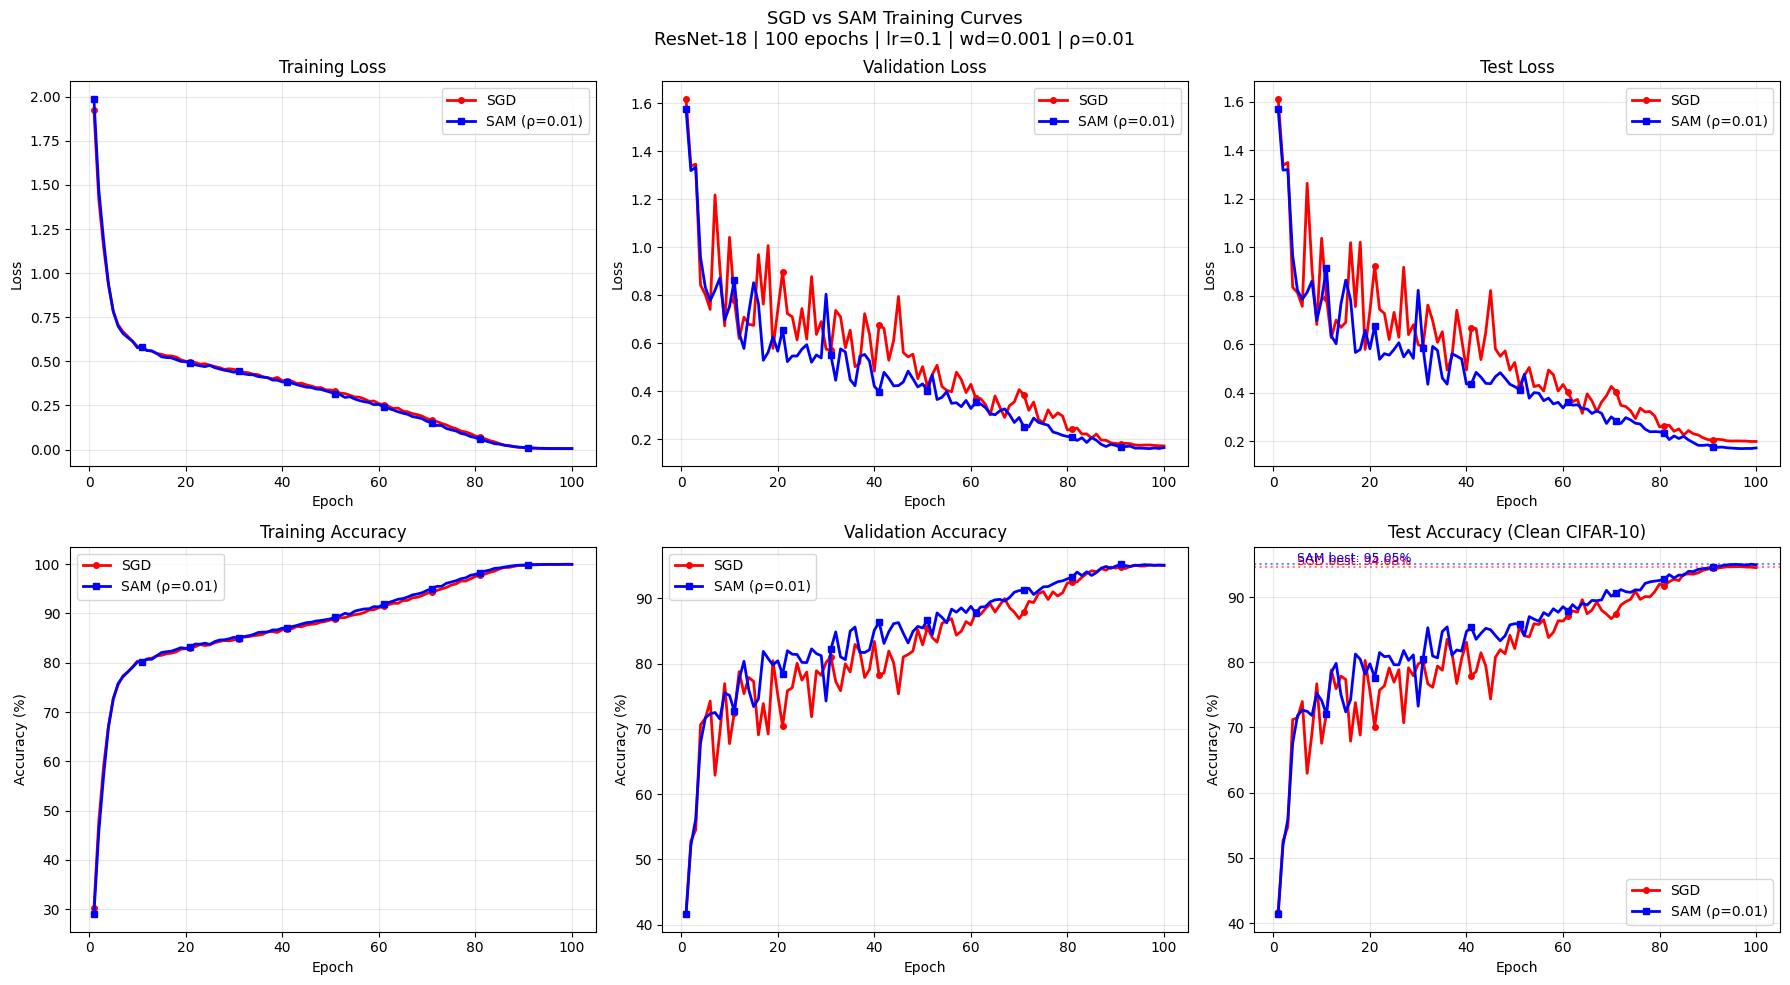


📊 Training results summary:
   SGD — Best Val: 95.08%  Final Test: 94.65%
   SAM — Best Val: 95.20%  Final Test: 94.69%


In [ ]:
# ============================================================
# CELL 11: Training-curve comparison plots (Train / Val / Test)
# ============================================================

epochs_range = np.arange(1, EPOCHS + 1)
mk = max(1, EPOCHS // 10)    # marker interval

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Training loss ───────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs_range, sgd_history['train_loss'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['train_loss'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Validation loss ─────────────────────────────────────────
ax = axes[0, 1]
ax.plot(epochs_range, sgd_history['val_loss'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['val_loss'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Validation Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Test loss ───────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(epochs_range, sgd_history['test_loss'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['test_loss'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Test Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Training accuracy ───────────────────────────────────────
ax = axes[1, 0]
ax.plot(epochs_range, sgd_history['train_acc'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['train_acc'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Training Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Validation accuracy ─────────────────────────────────────
ax = axes[1, 1]
ax.plot(epochs_range, sgd_history['val_acc'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['val_acc'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Validation Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Test accuracy ───────────────────────────────────────────
ax = axes[1, 2]
ax.plot(epochs_range, sgd_history['test_acc'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['test_acc'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
sgd_best = max(sgd_history['test_acc'])
sam_best = max(sam_history['test_acc'])
ax.axhline(sgd_best, color='r', ls=':', alpha=0.5)
ax.axhline(sam_best, color='b', ls=':', alpha=0.5)
ax.text(EPOCHS*0.05, sgd_best+0.3, f'SGD best: {sgd_best:.2f}%', color='r', fontsize=9)
ax.text(EPOCHS*0.05, sam_best+0.3, f'SAM best: {sam_best:.2f}%', color='b', fontsize=9)
ax.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Test Accuracy (Clean CIFAR-10)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'SGD vs SAM Training Curves\n'
    f'ResNet-18 | {EPOCHS} epochs | lr={LR} | wd={WEIGHT_DECAY} | ρ={SAM_RHO_TRAIN}',
    fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Training results summary:')
print(f'   SGD — Best Val: {sgd_history["best_val_acc"]:.2f}%  '
      f'Final Test: {sgd_history["final_test_acc"]:.2f}%')
print(f'   SAM — Best Val: {sam_history["best_val_acc"]:.2f}%  '
      f'Final Test: {sam_history["final_test_acc"]:.2f}%')


---
## PART 3 — OOD Robustness Evaluation (Using the Official CIFAR-10-C Dataset)

Using the official [CIFAR-10-C](https://zenodo.org/record/2535967) dataset released by **Hendrycks & Dietterich (2019)**,
evaluate model robustness on real corruption data.

CIFAR-10-C contains **19 corruption types** × **5 severity levels**, with 10,000 images per (corruption, severity) group,
and the labels are identical to those of the original CIFAR-10 test set (we reuse `cifar10_labels.npy` directly).

| Category | Included types |
|---------|----------|
| Noise   | gaussian_noise, shot_noise, impulse_noise |
| Blur    | defocus_blur, glass_blur, motion_blur, zoom_blur |
| Weather | snow, frost, fog, brightness |
| Digital | contrast, elastic_transform, pixelate, jpeg_compression |

> ⚠️ **Data download**: the script downloads from Zenodo automatically (~800 MB); the first run on Colab takes about 2–5 minutes.
> If already downloaded, this step is skipped.


In [ ]:
# ============================================================
# CELL 12: Download and load the official CIFAR-10-C dataset
# Data source: Hendrycks & Dietterich (2019)
# https://zenodo.org/record/2535967
# ============================================================

import os
import urllib.request
import tarfile
import numpy as np

CIFAR10C_DIR = './data/CIFAR-10-C'
CIFAR10C_URL = 'https://zenodo.org/record/2535967/files/CIFAR-10-C.tar'

# ---- Auto-download (if not already downloaded) ----
if not os.path.isdir(CIFAR10C_DIR):
    os.makedirs('./data', exist_ok=True)
    print('Downloading CIFAR-10-C (~800 MB)...')
    tar_path = './data/CIFAR-10-C.tar'

    def _progress(block_num, block_size, total_size):
        done = block_num * block_size
        pct  = min(done / total_size * 100, 100)
        if block_num % 500 == 0:
            print(f'  {pct:.1f}%  ({done/1e6:.0f} / {total_size/1e6:.0f} MB)', end='\r')

    urllib.request.urlretrieve(CIFAR10C_URL, tar_path, reporthook=_progress)
    print('\nExtracting...')
    with tarfile.open(tar_path) as tar:
        tar.extractall('./data')
    os.remove(tar_path)
    print('✅ Download complete:', CIFAR10C_DIR)
else:
    print('✅ CIFAR-10-C already exists, skipping download')

# ---- List available corruption types ----
npy_files = sorted([
    f[:-4] for f in os.listdir(CIFAR10C_DIR)
    if f.endswith('.npy') and f != 'labels.npy'
])
print(f'\nFound {len(npy_files)} corruption types:')
for i, name in enumerate(npy_files):
    print(f'  {i+1:2d}. {name}')

# ---- Load labels (shared across all corruptions) ----
CIFAR10C_LABELS = np.load(os.path.join(CIFAR10C_DIR, 'labels.npy'))
# labels.npy shape: (50000,) — 5 severity × 10000 images, stacked

CIFAR10C_CORRUPTIONS = npy_files  # all 19, or filter as needed

# CIFAR-10 normalization parameters (same as during training)
CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
CIFAR_STD  = torch.tensor([0.2470, 0.2435, 0.2616])

print(f'\n✅ Labels loaded, shape: {CIFAR10C_LABELS.shape}')
print(f'   Evaluation scenarios: {len(CIFAR10C_CORRUPTIONS)} corruptions × 5 severities = {len(CIFAR10C_CORRUPTIONS)*5} groups')


Extracting...
✅ Download complete:  ./data/CIFAR-10-C

Found 19 corruption types:
   1. brightness
   2. contrast
   3. defocus_blur
   4. elastic_transform
   5. fog
   6. frost
   7. gaussian_blur
   8. gaussian_noise
   9. glass_blur
  10. impulse_noise
  11. jpeg_compression
  12. motion_blur
  13. pixelate
  14. saturate
  15. shot_noise
  16. snow
  17. spatter
  18. speckle_noise
  19. zoom_blur

✅ Labels loaded, shape: (50000,)
   Evaluation scenarios: 19 corruptions × 5 severities = 95 groups


In [ ]:
# ============================================================
# CELL 13: OOD robustness evaluation (official CIFAR-10-C)
# ============================================================

from torch.utils.data import TensorDataset, DataLoader as DL

@torch.no_grad()
def evaluate_cifar10c(model, corruption_name, severity, device, batch_size=256):
    """
    Evaluate model accuracy on a given corruption type + severity.

    CIFAR-10-C file layout:
      Each .npy file has shape = (50000, 32, 32, 3), dtype uint8, value range [0, 255].
      First 10000 images = severity 1, ..., last 10000 = severity 5.
    Labels: labels.npy has shape = (50000,) in the same order.
    """
    model.eval()

    npy_path = os.path.join(CIFAR10C_DIR, f'{corruption_name}.npy')
    data_all  = np.load(npy_path)          # (50000, 32, 32, 3) uint8
    label_all = CIFAR10C_LABELS            # (50000,)

    # Take the 10000 images corresponding to the requested severity
    start = (severity - 1) * 10000
    end   = severity * 10000
    data  = data_all[start:end]            # (10000, 32, 32, 3)
    labels = label_all[start:end]          # (10000,)

    # uint8 → float [0,1] → (N, C, H, W)
    x = torch.from_numpy(data).float() / 255.0          # (N,32,32,3)
    x = x.permute(0, 3, 1, 2)                           # (N,3,32,32)

    # CIFAR-10 normalization
    mean = CIFAR_MEAN.view(1, 3, 1, 1)
    std  = CIFAR_STD.view(1, 3, 1, 1)
    x = (x - mean) / std

    y = torch.from_numpy(labels).long()

    dataset = TensorDataset(x, y)
    loader  = DL(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    correct, total = 0, 0
    for images, lbls in loader:
        images, lbls = images.to(device), lbls.to(device)
        outputs = model(images)
        correct += outputs.argmax(1).eq(lbls).sum().item()
        total   += lbls.size(0)

    return 100.0 * correct / total


# ---- Run full evaluation ----
# Can evaluate all 19, or only an interesting subset
EVAL_CORRUPTIONS = CIFAR10C_CORRUPTIONS  # all; or replace with e.g. ['gaussian_noise', 'motion_blur', 'snow']

print(f'Starting OOD robustness evaluation: {len(EVAL_CORRUPTIONS)} corruptions × 5 severities')
print(f'{"Corruption":<25} | {"Sev":>3} | {"SGD":>7} | {"SAM":>7} | {"Δ":>6}')
print('-' * 60)

results = {}

for c_name in EVAL_CORRUPTIONS:
    results[c_name] = {'SGD': [], 'SAM': []}
    for sev in range(1, 6):
        sgd_acc = evaluate_cifar10c(sgd_model, c_name, sev, device)
        sam_acc = evaluate_cifar10c(sam_model, c_name, sev, device)
        results[c_name]['SGD'].append(sgd_acc)
        results[c_name]['SAM'].append(sam_acc)
        delta = sam_acc - sgd_acc
        print(f'{c_name:<25} | {sev:>3} | {sgd_acc:>6.1f}% | {sam_acc:>6.1f}% | '
              f'{delta:>+5.1f}%')

# ---- mCE (mean Corruption Error) ----
sgd_mCE = np.mean([100 - acc for c in results for acc in results[c]['SGD']])
sam_mCE = np.mean([100 - acc for c in results for acc in results[c]['SAM']])

clean_sgd = sgd_history['test_acc'][-1]
clean_sam = sam_history['test_acc'][-1]

print(f'\n📊 OOD robustness summary (official CIFAR-10-C):')
print(f'   Clean test set: SGD={clean_sgd:.2f}%  SAM={clean_sam:.2f}%')
print(f'   mCE (lower is better): SGD={sgd_mCE:.2f}%  SAM={sam_mCE:.2f}%')
print(f'   SAM improvement: {sgd_mCE - sam_mCE:+.2f}%')


Starting OOD robustness evaluation: 19 corruptions × 5 severities
Corruption                | Sev |     SGD |     SAM |      Δ
------------------------------------------------------------
brightness                |   1 |   94.3% |   94.5% |  +0.1%
brightness                |   2 |   94.1% |   94.2% |  +0.1%
brightness                |   3 |   93.3% |   93.5% |  +0.3%
brightness                |   4 |   92.6% |   92.5% |  -0.0%
brightness                |   5 |   90.0% |   89.8% |  -0.2%
contrast                  |   1 |   94.0% |   94.2% |  +0.2%
contrast                  |   2 |   90.7% |   91.1% |  +0.4%
contrast                  |   3 |   86.6% |   86.9% |  +0.3%
contrast                  |   4 |   76.2% |   78.3% |  +2.1%
contrast                  |   5 |   33.0% |   38.9% |  +5.9%
defocus_blur              |   1 |   94.5% |   94.5% |  +0.0%
defocus_blur              |   2 |   92.9% |   93.2% |  +0.3%
defocus_blur              |   3 |   87.0% |   88.6% |  +1.6%
defocus_blur       

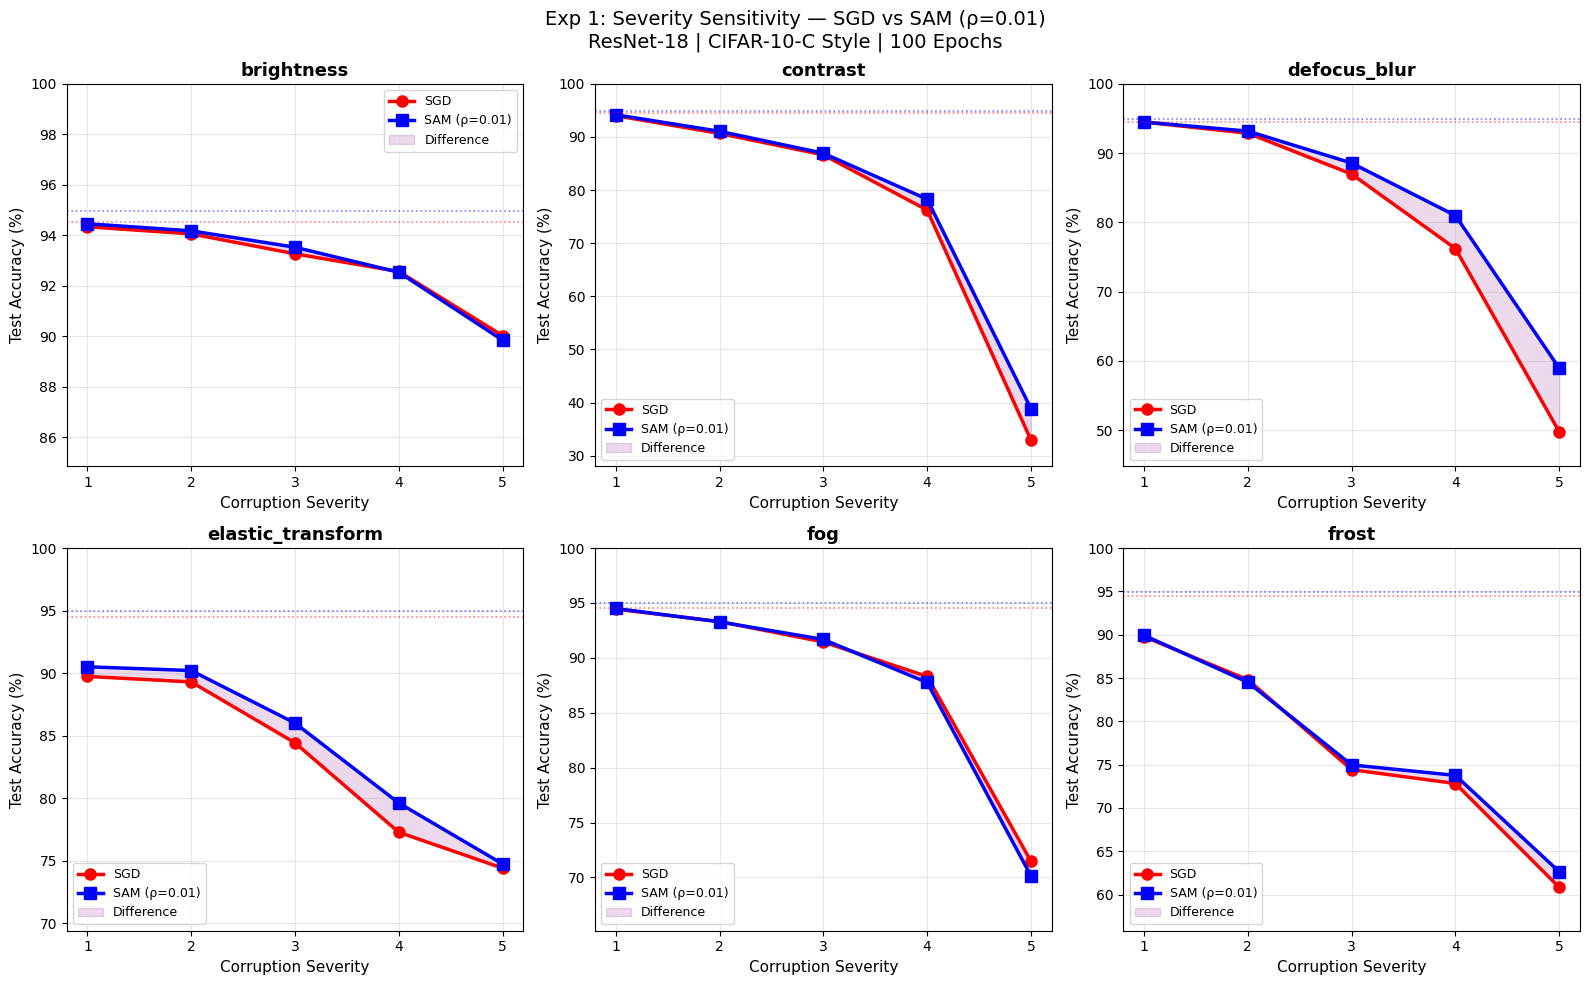

Plot saved to exp1_severity_sensitivity.png


In [ ]:
# ============================================================
# CELL 14: Exp 1 — Severity-sensitivity analysis plot
# (Corresponds to Exp 1 in the midterm: Track performance decay by severity)
# ============================================================

severity_levels = [1, 2, 3, 4, 5]
corruption_names = list(results.keys())
n_corruptions = len(corruption_names)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (c_name, ax) in enumerate(zip(corruption_names, axes)):
    sgd_accs = results[c_name]['SGD']
    sam_accs = results[c_name]['SAM']

    ax.plot(severity_levels, sgd_accs, 'r-o', linewidth=2.5,
            markersize=8, label='SGD')
    ax.plot(severity_levels, sam_accs, 'b-s', linewidth=2.5,
            markersize=8, label=f'SAM (ρ={SAM_RHO_TRAIN})')

    # Mark the clean baseline
    ax.axhline(clean_sgd, color='r', linestyle=':', alpha=0.5, linewidth=1.2)
    ax.axhline(clean_sam, color='b', linestyle=':', alpha=0.5, linewidth=1.2)

    # Shade the difference region between the two curves
    ax.fill_between(severity_levels,
                    [min(s, g) for s, g in zip(sam_accs, sgd_accs)],
                    [max(s, g) for s, g in zip(sam_accs, sgd_accs)],
                    alpha=0.15, color='purple', label='Difference')

    display_name = c_name.replace('\n', ' ')
    ax.set_title(display_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Corruption Severity', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.set_xticks(severity_levels)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(max(0, min(min(sgd_accs), min(sam_accs)) - 5), 100)

plt.suptitle(
    f'Exp 1: Severity Sensitivity — SGD vs SAM (ρ={SAM_RHO_TRAIN})\n'
    f'ResNet-18 | CIFAR-10-C Style | {EPOCHS} Epochs',
    fontsize=14
)
plt.tight_layout()
plt.savefig('exp1_severity_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to exp1_severity_sensitivity.png')

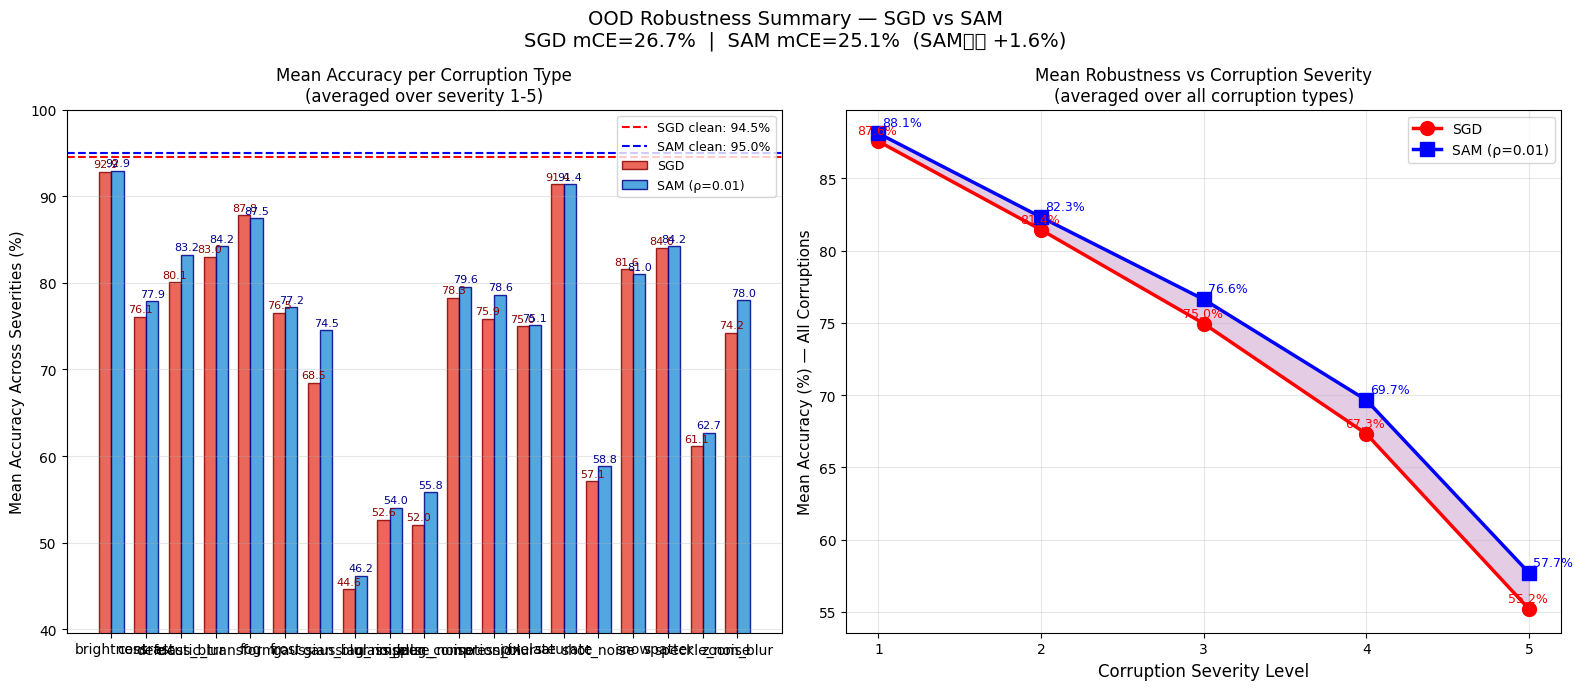

Plot saved to robustness_summary.png


In [ ]:
# ============================================================
# CELL 15: Comprehensive comparison plot (radar + bar chart)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---- Left: bar chart of mean accuracy per corruption ----
ax = axes[0]

display_names = [c.replace('\n', ' ') for c in corruption_names]
sgd_mean_per_corruption = [np.mean(results[c]['SGD']) for c in corruption_names]
sam_mean_per_corruption = [np.mean(results[c]['SAM']) for c in corruption_names]

x = np.arange(len(corruption_names))
width = 0.35
bars_sgd = ax.bar(x - width/2, sgd_mean_per_corruption, width,
                   color='#E74C3C', alpha=0.85, label='SGD', edgecolor='darkred')
bars_sam = ax.bar(x + width/2, sam_mean_per_corruption, width,
                   color='#3498DB', alpha=0.85, label=f'SAM (ρ={SAM_RHO_TRAIN})', edgecolor='darkblue')

# Annotate values
for bar in bars_sgd:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='darkred')
for bar in bars_sam:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='darkblue')

# Clean baseline
ax.axhline(clean_sgd, color='r', linestyle='--', linewidth=1.5,
            label=f'SGD clean: {clean_sgd:.1f}%')
ax.axhline(clean_sam, color='b', linestyle='--', linewidth=1.5,
            label=f'SAM clean: {clean_sam:.1f}%')

ax.set_xticks(x)
ax.set_xticklabels(display_names, fontsize=10)
ax.set_ylabel('Mean Accuracy Across Severities (%)', fontsize=11)
ax.set_title('Mean Accuracy per Corruption Type\n(averaged over severity 1-5)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(max(0, min(min(sgd_mean_per_corruption), min(sam_mean_per_corruption)) - 5), 100)

# ---- Right: line chart of mean accuracy per severity ----
ax2 = axes[1]

sgd_mean_per_severity = [
    np.mean([results[c]['SGD'][s] for c in corruption_names])
    for s in range(5)
]
sam_mean_per_severity = [
    np.mean([results[c]['SAM'][s] for c in corruption_names])
    for s in range(5)
]

ax2.plot(severity_levels, sgd_mean_per_severity, 'r-o',
          linewidth=2.5, markersize=10, label='SGD')
ax2.plot(severity_levels, sam_mean_per_severity, 'b-s',
          linewidth=2.5, markersize=10, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax2.fill_between(severity_levels,
                  [min(s, g) for s, g in zip(sam_mean_per_severity, sgd_mean_per_severity)],
                  [max(s, g) for s, g in zip(sam_mean_per_severity, sgd_mean_per_severity)],
                  alpha=0.2, color='purple')

# Annotate values
for s, (sg, sm) in enumerate(zip(sgd_mean_per_severity, sam_mean_per_severity)):
    ax2.annotate(f'{sg:.1f}%', (s+1, sg), textcoords='offset points',
                  xytext=(-15, 5), fontsize=9, color='r')
    ax2.annotate(f'{sm:.1f}%', (s+1, sm), textcoords='offset points',
                  xytext=(3, 5), fontsize=9, color='b')

ax2.set_xlabel('Corruption Severity Level', fontsize=12)
ax2.set_ylabel('Mean Accuracy (%) — All Corruptions', fontsize=11)
ax2.set_title('Mean Robustness vs Corruption Severity\n(averaged over all corruption types)', fontsize=12)
ax2.set_xticks(severity_levels)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f'OOD Robustness Summary — SGD vs SAM\n'
    f'SGD mCE={sgd_mCE:.1f}%  |  SAM mCE={sam_mCE:.1f}%  '
    f'(SAM improvement {sgd_mCE-sam_mCE:+.1f}%)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('robustness_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to robustness_summary.png')

In [ ]:
# ============================================================
# CELL 17: Final results summary table
# ============================================================

print('\n' + '='*65)
print('  FINAL RESULTS SUMMARY')
print('='*65)
print(f'  Model Architecture : ResNet-18 (CIFAR-adapted)')
print(f'  Training Epochs    : {EPOCHS}')
print(f'  Batch Size         : {BATCH_SIZE}')
print(f'  Learning Rate      : {LR}')
print(f'  Momentum           : {MOMENTUM}')
print(f'  Weight Decay       : {WEIGHT_DECAY}')
print(f'  SAM ρ              : {SAM_RHO_TRAIN}')
print('='*65)
print(f'  {"Metric":<35} {"SGD":>8} {"SAM":>8} {"Δ":>8}')
print('-'*65)
print(f'  {"Clean Test Accuracy":35} {clean_sgd:>7.2f}% {clean_sam:>7.2f}% {clean_sam-clean_sgd:>+7.2f}%')
print(f'  {"Mean Corruption Error (mCE)":35} {sgd_mCE:>7.2f}% {sam_mCE:>7.2f}% {sam_mCE-sgd_mCE:>+7.2f}%')
print('-'*65)

for c_name in corruption_names:
    display = c_name.replace('\n', ' ')
    sgd_m = np.mean(results[c_name]['SGD'])
    sam_m = np.mean(results[c_name]['SAM'])
    print(f'  Mean Acc: {display:<25} {sgd_m:>7.2f}% {sam_m:>7.2f}% {sam_m-sgd_m:>+7.2f}%')


  FINAL RESULTS SUMMARY
  Model Architecture : ResNet-18 (CIFAR-adapted)
  Training Epochs    : 100
  Batch Size         : 128
  Learning Rate      : 0.1
  Momentum           : 0.9
  Weight Decay       : 0.001
  SAM ρ              : 0.01
  Metric                                   SGD      SAM        Δ
-----------------------------------------------------------------
  Clean Test Accuracy                   94.52%   94.96%   +0.44%
  Mean Corruption Error (mCE)           26.71%   25.12%   -1.59%
-----------------------------------------------------------------
  Mean Acc: brightness                  92.85%   92.91%   +0.06%
  Mean Acc: contrast                    76.10%   77.87%   +1.77%
  Mean Acc: defocus_blur                80.06%   83.23%   +3.17%
  Mean Acc: elastic_transform           83.03%   84.22%   +1.19%
  Mean Acc: fog                         87.80%   87.47%   -0.33%
  Mean Acc: frost                       76.53%   77.16%   +0.63%
  Mean Acc: gaussian_blur               68.4